## TASK 2 — Chi‑Square (Independence)

In [14]:
# import libraries
import pandas as pd, yfinance as yf

# select assets and benchmark
TICKER = ["NVDA", "AMD", "INTC"]
BENCH  = ["QQQ"] 
TICKER = TICKER + BENCH

# 3 year period
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(months=36)

# download adjusted close prices
df = yf.download(TICKER, start=start, end=end, interval="1d", auto_adjust=True)[["Close"]]

# flatten column names if multi-index
# i am not sure why the template appends an extra index on the columns
df.columns = [col if isinstance(col, str) else col[1] for col in df.columns]

# reset index to make Date a column
df = df.reset_index()

# sort values by date
df = df.sort_values("Date")

# forward fill and drop any NAs
df = df.ffill().dropna()

# compute returns
df_returns = df[TICKER].pct_change().rename(columns=lambda x: x+ "_Return")

# align return columns to match df
price_cols = df.columns[1:]
df_returns = df_returns[[col + "_Return" for col in price_cols]]

# concatting two datas
df = pd.concat([df, df_returns], axis=1)

# fill returns of the first row to 0
df.fillna(0, inplace=True)

# convert necessary variables to numeric
# consumes a lot of time despite values being numeric already
variables = TICKER + [t + "_Return" for t in TICKER]
for v in variables:
    df[v] = pd.to_numeric(df[v], errors='coerce')

# save files
df.to_csv("prices_clean.csv", index=False)

# ==============================
# TRANSFORMING QUANTITATIVE DATA
# ==============================

# compress wide-format returns into long format
long_df = df.melt(id_vars="Date", value_vars=[t + "_Return" for t in TICKER], var_name="Ticker", value_name="Return")

# clean ticker names
long_df["Ticker"] = long_df["Ticker"].str.replace("_Return", "")

# convert ticker to categorical variables
long_df["Ticker"] = long_df["Ticker"].astype("category")

# save files
long_df.to_csv("returns_long_format.csv", index=False)

[*********************100%***********************]  4 of 4 completed


## Construct assignment variables

In [15]:
import numpy as np
import scipy.stats as st

# Load long-format returns
df = pd.read_csv("returns_long_format.csv", parse_dates=["Date"])

# Up/Down label
df["UpDown"] = np.where(df["Return"] > 0, "UP", "DOWN")

# Day-of-Week
df["DoW"] = df["Date"].dt.day_name()  # Monday, Tuesday, etc.

# simple moving averages for regime (Bull/Bear)
# we'll compute these per Ticker
sma_window_short = 50
sma_window_long = 200

# it's better to compute per Ticker
tickers = df["Ticker"].unique()
regime_list = []

for t in tickers:
    sub = df[df["Ticker"] == t].copy()
    # compute the rolling average
    sub["SMA50"] = sub["Return"].rolling(sma_window_short).mean()  # or use price if available
    sub["SMA200"] = sub["Return"].rolling(sma_window_long).mean()
    # regime, Bull if SMA50 > SMA200, else Bear
    sub["Regime"] = np.where(sub["SMA50"] > sub["SMA200"], "Bull", "Bear")
    regime_list.append(sub)

df = pd.concat(regime_list)

## Chi-square test: Up/Down vs Day-of-Week

In [16]:
# contigency table
ct = pd.crosstab(df["UpDown"], df["DoW"])
print("Contingency Table (Up/Down vs DoW):\n", ct, "\n")

# chi-square
chi2, p, dof, expected = st.chi2_contingency(ct)

print("Expected Counts:\n", pd.DataFrame(expected, index=ct.index, columns=ct.columns), "\n")
print(f"Chi-square statistic = {chi2}")
print(f"p-value = {p}")
print(f"Degrees of freedom = {dof}")

# Cramer's V
n = ct.values.sum()
phi2 = chi2 / n
r, k = ct.shape
cramers_v = np.sqrt(phi2 / min(r-1, k-1))
print(f"Cramer's V = {cramers_v}")

Contingency Table (Up/Down vs DoW):
 DoW     Friday  Monday  Thursday  Tuesday  Wednesday
UpDown                                              
DOWN       291     231       282      308        297
UP         321     325       322      312        319 

Expected Counts:
 DoW         Friday     Monday    Thursday     Tuesday   Wednesday
UpDown                                                           
DOWN    286.671543  260.44016  282.924202  290.418883  288.545213
UP      325.328457  295.55984  321.075798  329.581117  327.454787 

Chi-square statistic = 8.85721067150656
p-value = 0.06476933071855825
Degrees of freedom = 4
Cramer's V = 0.05426372103024933


## Stacked bar

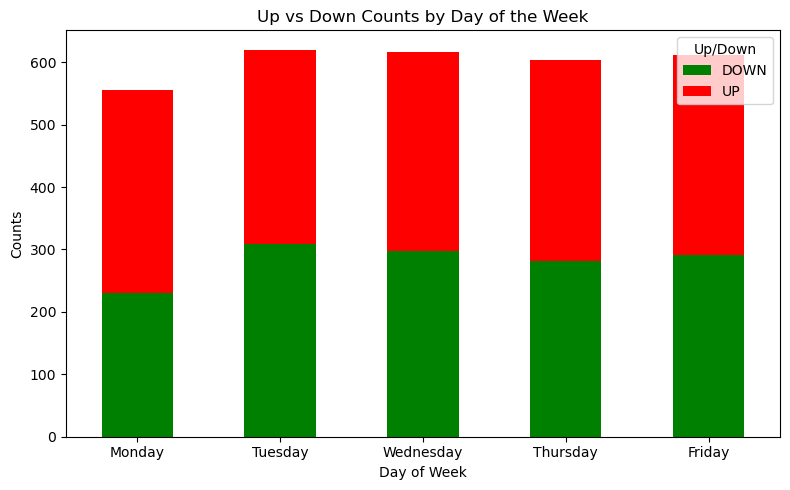

In [26]:
import matplotlib.pyplot as plt

# Ensure DoW is categorical with proper order
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
df["DoW"] = pd.Categorical(df["DoW"], categories=days_order, ordered=True)

# Create contingency table: DoW as rows, UpDown as columns
ct = pd.crosstab(df["DoW"], df["UpDown"])

# Plot stacked bar
ct.plot(kind="bar",
        stacked=True,
        color=["green", "red"],  # UP = green, DOWN = red
        figsize=(8,5))

plt.title("Up vs Down Counts by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Counts")
plt.xticks(rotation=0)
plt.legend(title="Up/Down")
plt.tight_layout()
plt.show()